In [1]:
import warnings

warnings.simplefilter("ignore", FutureWarning)

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import scanpy as sc
import squidpy as sq
import anndata as ad


/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/numba/core/decorators.py:246: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)


In [2]:
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
#%matplotlib inline
sc.settings.figdir = "fig4"
sc.settings.set_figure_params(dpi=50, dpi_save=300, facecolor="white", frameon=False, figsize=(8,8),
                                   vector_friendly=True
                             )


# Load

In [3]:
adata=sc.read_h5ad('/nfs/team298/ls34/adult_skin/final_adatas/adata_combined_new.h5ad.final.filtered.scrna')
import gc
gc.collect()
adata.obs["lvl5_annotation_new"]=adata.obs["lvl5_annotation"]

 

In [4]:
[x for x in adata.obs["dataset_id"].unique() if "bangert" in x.lower()]

['Bangert_AD']

In [5]:
# adata.write('/nfs/team298/ls34/adult_skin/final_adatas/adata_skin_scrna_subsampled.h5ad')

In [5]:
adata_i=adata[adata.obs["dataset_id"]=="Bangert_AD"]

In [6]:
sc.pp.normalize_total(adata_i, target_sum=1e4)
sc.pp.log1p(adata_i)


/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/scanpy/preprocessing/_normalization.py:169: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


In [9]:
[x for x in adata_i.obs["lvl5_annotation"].unique() if "sweat" in x.lower()]

['Sweat gland channel outer', 'Sweat gland Myoepithelial']

In [10]:
adata_ii=adata_i[adata_i.obs["lvl5_annotation"]=='Sweat gland channel outer']
adata_ii

View of AnnData object with n_obs × n_vars = 13 × 32732
    obs: 'sample_id', 'barcode', 'GSE', 'Site_status', 'Patient_status', 'Location', 'Age', 'Sex', 'n_genes', 'dataset_id', 'n_genes_by_counts', 'total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'QC_hi', 'QC_mid', 'lvl5_annotation', 'Mapping_status', 'scanvi_predictions', 'lvl5_annotation_new', 'lvl5_annotation_new2', 'lvl5_annotation_new3', 'lvl5_annotation_new_archive', 'lvl5_annotation_new_preoprhan', 'lvl5_annotation_new10', 'lvl5_annotation_new11', 'test', 'test_n', 'lvl5_annotation_new12', 'lvl5_annotation_new13', 'lvl4_annotation', 'lvl0', 'temp', 't', 'leiden_res0.1', 'Site_status_simple', 'StatusMilo', 'atlas_status', 'atlas_status_reynolds', 'atlas_status_reynolds_simple', 'atlas_status_simple', 'atlas_status_simple2', 'Site_status_binary', 'lvl1_new'
    uns

In [12]:
adata_ii=adata[adata.obs["lvl5_annotation"]=='Sweat gland']
adata_ii

View of AnnData object with n_obs × n_vars = 19599 × 32732
    obs: 'sample_id', 'barcode', 'GSE', 'Site_status', 'Patient_status', 'Location', 'Age', 'Sex', 'n_genes', 'dataset_id', 'n_genes_by_counts', 'total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'QC_hi', 'QC_mid', 'lvl5_annotation', 'Mapping_status', 'scanvi_predictions', 'lvl5_annotation_new', 'lvl5_annotation_new2', 'lvl5_annotation_new3', 'lvl5_annotation_new_archive', 'lvl5_annotation_new_preoprhan', 'lvl5_annotation_new10', 'lvl5_annotation_new11', 'test', 'test_n', 'lvl5_annotation_new12', 'lvl5_annotation_new13', 'lvl4_annotation', 'lvl0', 'temp', 't', 'leiden_res0.1', 'Site_status_simple', 'StatusMilo', 'atlas_status', 'atlas_status_reynolds', 'atlas_status_reynolds_simple', 'atlas_status_simple', 'atlas_status_simple2', 'Site_status_binary', 'lvl1_new'
    

/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


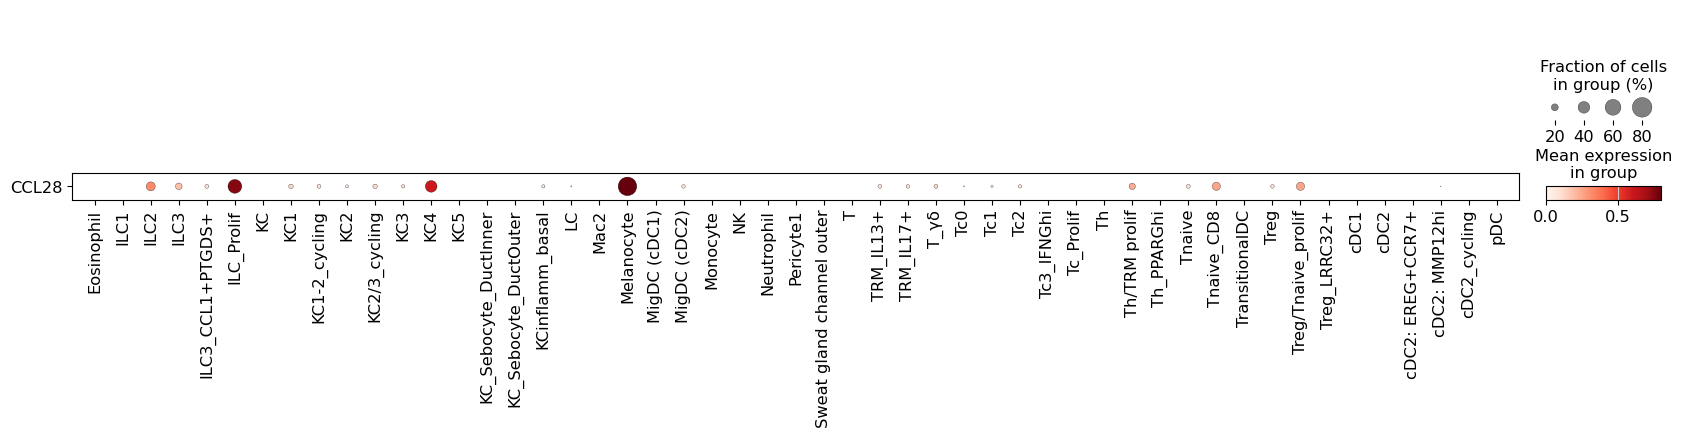

In [18]:
sc.pl.dotplot(
    adata[adata.obs["Site_status"]=="PostRx-Lesional Dupilumab (16 wk)"],
     [ 'CCL28', 
                 
                    ],
    groupby="lvl5_annotation",
    vmax=0.8,
    swap_axes=True,
       # dot_max=0.3,
  #  save='plotTNFRSF17_TNFSF13_scrna.pdf',
   #     title="TNFSF13(APRIL) + TNFRSF17 expression in scRNA"

    

  #  save='supp16_plasma_Cell_dotplot1_XENIUM_allcells.pdf'
)


/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


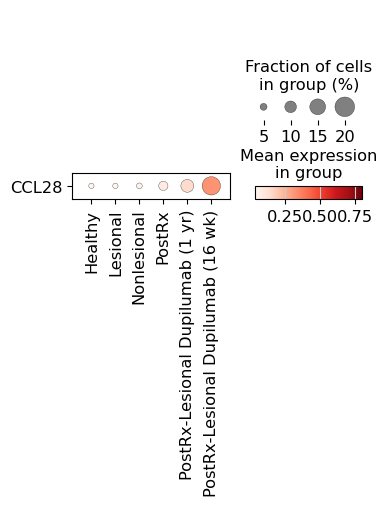

In [15]:
sc.pl.dotplot(
    adata,
     [ 'CCL28', 
                 
                    ],
    groupby="Site_status",
    vmax=0.8,
    swap_axes=True,
       # dot_max=0.3,
  #  save='plotTNFRSF17_TNFSF13_scrna.pdf',
   #     title="TNFSF13(APRIL) + TNFRSF17 expression in scRNA"

    

  #  save='supp16_plasma_Cell_dotplot1_XENIUM_allcells.pdf'
)


In [7]:
# sc.pl.dotplot(
#     adata,
#      [ 'CD38', 
                   
#                     ],
#     groupby="lvl5_annotation",
#     vmax=0.8,
#     swap_axes=True,
#        # dot_max=0.3,
#    # save='plotTNFRSF17_TNFSF13_scrna.pdf',
#       #  title="TNFSF13(APRIL) + TNFRSF17 expression in scRNA"

    

#   #  save='supp16_plasma_Cell_dotplot1_XENIUM_allcells.pdf'
# )


In [8]:
# sc.pl.dotplot(
#     adata,
#      [ 'TNFSF13', 
#                     'TNFRSF17'
#                     ],
#     groupby="lvl5_annotation",
#     vmax=0.8,
#     swap_axes=True,
#        # dot_max=0.3,
#     save='plotTNFRSF17_TNFSF13_scrna.pdf',
#         title="TNFSF13(APRIL) + TNFRSF17 expression in scRNA"

    

#   #  save='supp16_plasma_Cell_dotplot1_XENIUM_allcells.pdf'
# )


/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


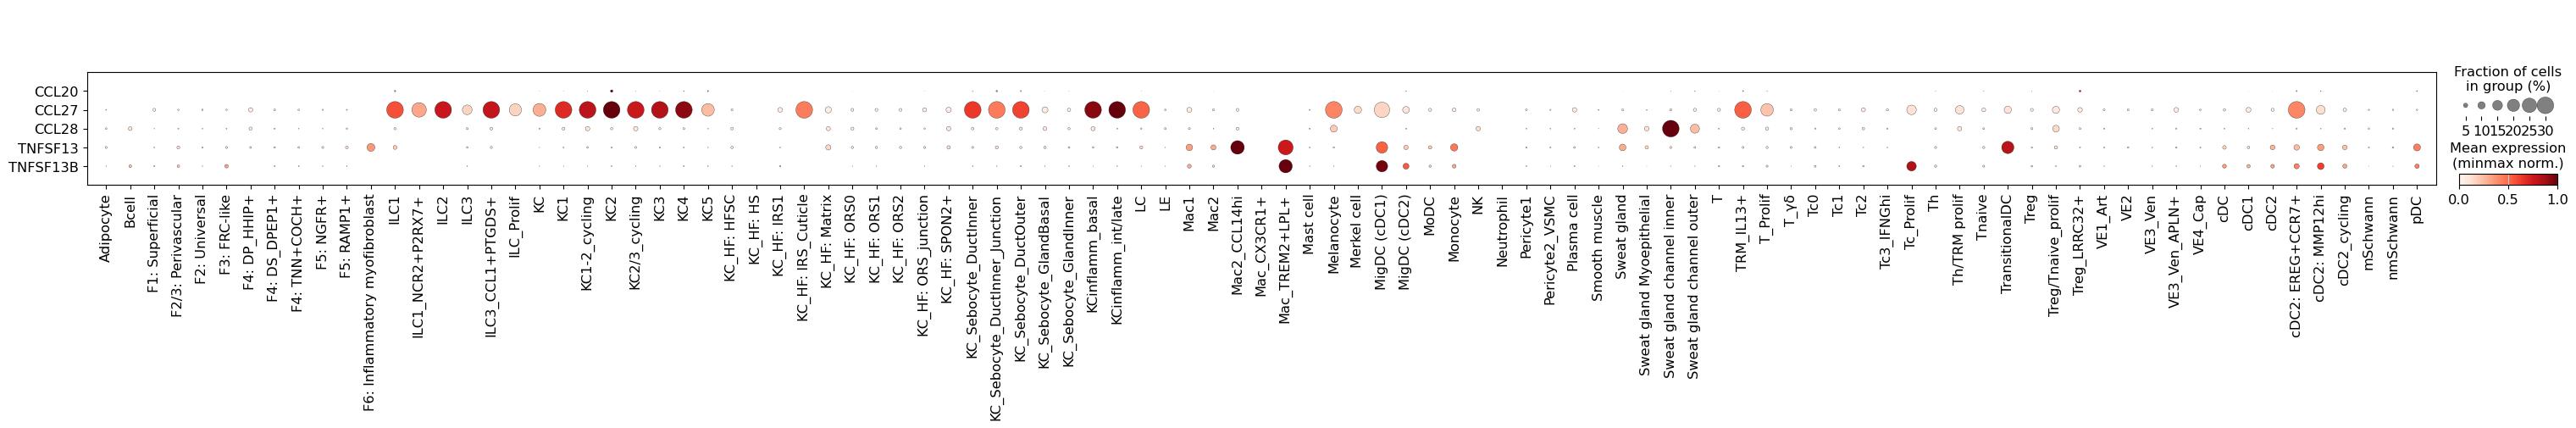

In [17]:
sc.pl.dotplot(
    adata[adata.obs["Patient_status"]=="AD"],
     ["CCL20",  "CCL27", "CCL28", 'TNFSF13', 'TNFSF13B',],
    groupby="lvl5_annotation",
  #  vmax=0.8,
  #  categories_order=ORDER,
        dot_max=0.3,
    standard_scale="var",
    colorbar_title="Mean expression\n(minmax norm.)",
    swap_axes=True,
    save="plasmacell_signalling_allcells.pdf"

   # save='4h_plasma_Cell_dotplot1.pdf'
)

# sc.pl.dotplot(
#     adata,
#        ["CCR2", "CCR6",  "CCR10", 'TNFRSF13B', 'TNFRSF13C', 'TNFRSF17'],
#     groupby="lvl5_annotation",
#     #vmax=0.8,
#     dot_max=0.3,
#         standard_scale="var",

#     categories_order=ORDER,
#     colorbar_title="Mean expression\n(minmax norm.)",
#   #  save='4h_plasma_Cell_dotplot2_minmax.pdf'
# )

# dp = dp.style(
#     cmap='Reds',
#     color_on='square',
#     dot_edge_color='white',
#     dot_edge_lw=1,
#     grid=False,
#     dot_max=0.6,
#     categories_order=ORDER
# )

# dp.savefig("fig5/", dpi=300)

# #dp.show()
   

In [ ]:
order = list(sorted(adata.obs["lvl5_annotation"].unique()))

priority = ["Plasma cell", "Bcell"]

order = priority + [x for x in order if x not in priority]

In [ ]:
sc.pl.dotplot(
    adata,
     [ "CD38",    'TNFRSF17', "CD79A",
                'TNFRSF13B', 'TNFRSF13C', "CD19", "MS4A1", 
                    ],
    groupby="lvl5_annotation",
    vmax=0.8,
    swap_axes=True,
       # dot_max=0.3,
    save='plot_PLASMAMARKERSFORPROTEIN.pdf',
    categories_order=order
      #  title="TNFSF13(APRIL) + TNFRSF17 expression in scRNA"

    

  #  save='supp16_plasma_Cell_dotplot1_XENIUM_allcells.pdf'
)


In [ ]:
sorted(adata.obs["lvl5_annotation"].unique())

In [ ]:
# stop

In [ ]:
adata_plasma=adata[(adata.obs["lvl5_annotation"]=="Plasma cell")|
                  (adata.obs["lvl5_annotation"]=="Bcell")
                  ]
adata_plasma.shape



In [ ]:
sc.pp.normalize_total(adata_plasma, target_sum=1e4)
sc.pp.log1p(adata_plasma)


In [ ]:
adata_plasma_l = adata_plasma[(adata_plasma.obs["Site_status"]=="Week 12")|
                              (adata_plasma.obs["Site_status"]=="Lesional")|
                              (adata_plasma.obs["Site_status"].str.startswith("3D"))|
                               (adata_plasma.obs["Site_status"]=="Psoriasis_replicate_Lesional")
                              
                               ]
adata_plasma_l.obs["t"] = adata_plasma_l.obs["lvl5_annotation"].astype(str)+"_" + adata_plasma_l.obs["Patient_status"].astype(str) + adata_plasma_l.obs["Site_status"].astype(str)

{x:x for x in adata_plasma_l.obs["t"].unique()}

RENAME = {'Plasma cell_ADLesional': 'Plasma cell_AD_Lesional',
 'Bcell_ADLesional': 'Bcell_AD_Lesional',
 'Bcell_ADWeek 12': 'Bcell_AD_Week12',
 'Plasma cell_ADWeek 12': 'Plasma cell_AD_Week12',
 'Plasma cell_PsoriasisLesional': 'Plasma cell_Psoriasis_Lesional',
 'Bcell_PsoriasisLesional': 'Bcell_Psoriasis_Lesional',
 'Bcell_nanPsoriasis_replicate_Lesional': 'Bcell_Psoriasis_Lesional',
 'Plasma cell_nanPsoriasis_replicate_Lesional': 'Plasma cell_Psoriasis_Lesional',
 'Bcell_3d_Lesional_baseline3D_Lesional_baseline': 'Bcell_AD_Lesional',
 'Plasma cell_3d_Lesional_baseline3D_Lesional_baseline': 'Plasma cell_AD_Lesional',
 'Bcell_3d_Week123D_Week12': 'Bcell_AD_Week12',
 'Plasma cell_3d_Week123D_Week12': 'Plasma cell_AD_Week12',
 'Plasma cell_3d_Lesional_baseline3D_Week12': 'Plasma cell_AD_Week12',
 'Bcell_3d_Lesional_baseline3D_Week12': 'Bcell_AD_Week12'}
adata_plasma_l.obs["t2"]=adata_plasma_l.obs["t"].map(RENAME)
adata_plasma_l.obs["t2"].value_counts()
# exclude = ['Bcell_nanPsoriasis_replicate_Lesional',
           
#           ]
# adata_plasma_l=adata_plasma_l[~adata_plasma_l.obs["t"].isin(exclude)]

In [ ]:
heavy_genes = ["IGHA1", "IGHA2", "IGHD","IGHE", "IGHG1", "IGHG2", "IGHG3", "IGHG4",  "IGHM", ]
sc.pl.dotplot(
    adata_plasma_l,
     heavy_genes,
    groupby="t2",
    vmax=0.8,
    swap_axes=True,
     dot_max=0.3,

    save='plotIGS_SCRNA.pdf',
    colorbar_title='Mean expression\n(log1p norm)'

)


In [ ]:

# adata_plasma.obs["t"] = adata_plasma.obs["lvl5_annotation"].astype(str)+"_" + adata_plasma.obs["Patient_status"].astype(str)
# heavy_genes = ["IGHM", "IGHD", "IGHG1", "IGHG2", "IGHG3", "IGHG4", "IGHA1", "IGHA2", "IGHE"]
# sc.pl.dotplot(
#     adata_plasma[adata_plasma.obs["Site_status_binary"]=="Lesional"],
#      heavy_genes,
#     groupby="t",
#     vmax=0.8,
#     swap_axes=True,
#      dot_max=0.3,

#     save='plotIGS.pdf',

# )


In [ ]:
# heavy_genes = ["IGHM", "IGHD", "IGHG1", "IGHG2", "IGHG3", "IGHG4", "IGHA1", "IGHA2", "IGHE"]
# sc.pl.dotplot(
#     adata_plasma[adata_plasma.obs["Site_status_binary"]=="Lesional"],
#      heavy_genes,
#     groupby="Patient_status",
#     vmax=2,
#     swap_axes=True,
#        dot_max=0.3,

#     save='plotIGS.pdf',
#     title="Ig expression in scRNA plasma cells by patient status"

# )


In [ ]:
# adata_plasma=adata[adata.obs["lvl5_annotation"]=="Bcell"]
# adata_plasma.shape

# heavy_genes = ["IGHM", "IGHD", "IGHG1", "IGHG2", "IGHG3", "IGHG4", "IGHA1", "IGHA2", "IGHE"]
# sc.pl.dotplot(
#     adata_plasma[adata_plasma.obs["Site_status_binary"]=="Lesional"],
#      heavy_genes,
#     groupby="Patient_status",
#     vmax=2,
#     swap_axes=True,
#        dot_max=0.3,

#     save='plotIGS_Bcell.pdf',
#     title="Ig expression in scRNA B-cells by patient status"

# )


In [ ]:
cell_types = [
    "cDC1",
    "Mac2",
    "T",
    "Pericyte1",
    "Ve3_Ven",
    "Plasma cell",
    "Bcell",
    "F3: FRC-like",
    "VE1_Art",'VE3_Ven',
    "VE4_Cap",
   # 'mSchwann',
    #'nmSchwann',
    "F2/3: Perivascular"
]

ORDER = [


 'Plasma cell',
     "Bcell",
 'Sweat gland Myoepithelial',
         'Sweat gland',
          'Sweat gland channel outer',
 'Sweat gland channel inner',
 'VE1_Art','VE3_Ven',
 'VE4_Cap',
    'Mac2',
 'T',

 'cDC1',
'F3: FRC-like', "F2/3: Perivascular", 'Pericyte1', 
    
    # 'mSchwann',
   # 'nmSchwann',
]

adata=adata[(adata.obs["lvl5_annotation"].isin(cell_types))|
           (adata.obs["lvl5_annotation"].str.startswith("Sweat"))
           ].copy()


In [ ]:
import gc
gc.collect()

In [ ]:
sc.pl.dotplot(
    adata,
     ["CCL2", "CCL20",  "CCL27", "CCL28", 'TNFSF13', 'TNFSF13B'],
    groupby="lvl5_annotation",
    vmax=0.8,
    categories_order=ORDER,
        dot_max=0.3,

    save='4h_plasma_Cell_dotplot1.pdf'
)

sc.pl.dotplot(
    adata,
       ["CCR2", "CCR6",  "CCR10", 'TNFRSF13B', 'TNFRSF13C', 'TNFRSF17'],
    groupby="lvl5_annotation",
    vmax=0.8,
    dot_max=0.3,
    categories_order=ORDER,
    colorbar_title="Mean expression\n(log1p norm)",
    save='4h_plasma_Cell_dotplot2.pdf'
)

# dp = dp.style(
#     cmap='Reds',
#     color_on='square',
#     dot_edge_color='white',
#     dot_edge_lw=1,
#     grid=False,
#     dot_max=0.6,
#     categories_order=ORDER
# )

# dp.savefig("fig5/", dpi=300)

# #dp.show()
   

In [ ]:
sc.pl.dotplot(
    adata,
     ["CCL2", "CCL20",  "CCL27", "CCL28", 'TNFSF13', 'TNFSF13B'],
    groupby="lvl5_annotation",
  #  vmax=0.8,
    categories_order=ORDER,
        dot_max=0.3,
    standard_scale="var",
    colorbar_title="Mean expression\n(minmax norm.)",

    save='4h_plasma_Cell_dotplot1.pdf'
)

sc.pl.dotplot(
    adata,
       ["CCR2", "CCR6",  "CCR10", 'TNFRSF13B', 'TNFRSF13C', 'TNFRSF17'],
    groupby="lvl5_annotation",
    #vmax=0.8,
    dot_max=0.3,
        standard_scale="var",

    categories_order=ORDER,
    colorbar_title="Mean expression\n(minmax norm.)",
    save='4h_plasma_Cell_dotplot2_minmax.pdf'
)

# dp = dp.style(
#     cmap='Reds',
#     color_on='square',
#     dot_edge_color='white',
#     dot_edge_lw=1,
#     grid=False,
#     dot_max=0.6,
#     categories_order=ORDER
# )

# dp.savefig("fig5/", dpi=300)

# #dp.show()
   

In [ ]:
sc.pl.dotplot(
    adata,
     ["PIGR",],
    groupby="lvl5_annotation",
    vmax=0.2,
    categories_order=ORDER,
        dot_max=0.2,
    colorbar_title="Mean expression\n(log1p norm)",
    save='supp_plasma_Cell_PIGRscrna.pdf'
)


In [ ]:
# sc.pl.dotplot(
#     adata[adata.obs["lvl5_annotation"]=="Sweat gland"],
#      ["PIGR"],
#     groupby="sample_id",
#     vmax=0.2,
#     #categories_order=ORDER,
#         dot_max=0.2,
#     colorbar_title="Mean expression\n(log1p norm)",
#     #save='supp_plasma_Cell_PIGRscrna.pdf'
# )
sc.pl.dotplot(
    adata[adata.obs["lvl5_annotation"]=="Sweat gland"],
     ["PIGR"],
    groupby="Site_status",
    vmax=0.2,
   # categories_order=ORDER,
        dot_max=0.2,
    colorbar_title="Mean expression\n(log1p norm)",
    #save='supp_plasma_Cell_PIGRscrna.pdf'
)


In [ ]:
sc.pl.dotplot(
    adata,
     ["PIGR", "FCGRT"],
    groupby="lvl5_annotation",
    vmax=0.2,
    categories_order=ORDER,
        dot_max=0.2,
    colorbar_title="Mean expression\n(log1p norm)",
   # save='supp_plasma_Cell_PIGRscrna.pdf'
)



In [ ]:
sc.pl.dotplot(
    adata,
     [ "FCGRT"],
    groupby="lvl5_annotation",
    #vmax=0.2,
    categories_order=ORDER,
       # dot_max=0.2,
    colorbar_title="Mean expression\n(log1p norm)",
   # save='supp_plasma_Cell_PIGRscrna.pdf'
)



In [ ]:
sc.pl.dotplot(
    adata,
     ["PIGR",],
    groupby="lvl5_annotation",
    vmax=0.3,
    categories_order=ORDER,
        dot_max=0.3,

    save='supp_plasma_Cell_PIGRscrna0.3.pdf'
)


# xenium validation (sFig 16b)

In [19]:
import scanpy as sc
adata=sc.read_h5ad('/nfs/team298/ls34/adult_skin/final_adatas/adata_combined_new.h5ad.final.filtered')
import gc
gc.collect()
adata=adata[adata.obs["tech"]=="xenium"]

def remove_markers(LIST):
    try: 
        LIST = {key: [gene for gene in genes if gene in adata.var_names] 
                           for key, genes in LIST.items()}
    except: 
        LIST =[gene for gene in LIST if gene in adata.var_names]
    return LIST

 


In [ ]:

# genes = adata.var.index.tolist()

# with open("/nfs/team298/ls34/xenium_genes.pkl", "wb") as f:
#     pickle.dump(genes, f)

In [20]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/scanpy/preprocessing/_normalization.py:169: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


In [ ]:
sc.pl.dotplot(
    adata[adata.obs["lvl5_annotation"]=="Plasma cell"],
     remove_markers(["CCL2", "CCL20",  "CCL27", "CCL28", 'TNFSF13', 'TNFSF13B']),
    groupby="niche19",
    vmax=0.8,
   # categories_order=ORDER,
        dot_max=0.3,

    #save='supp16_plasma_Cell_dotplot1_XENIUM.pdf'
)

sc.pl.dotplot(
    adata[adata.obs["lvl5_annotation"]=="Plasma cell"],
       remove_markers(["CCR2", "CCR6",  "CCR10", 'TNFRSF13B', 'TNFRSF13C', 'TNFRSF17']),
    groupby="niche19",
    vmax=0.8,
    dot_max=0.3,
    #categories_order=ORDER,
    colorbar_title="Mean expression\n(log1p norm)",
    #save='supp16_plasma_Cell_dotplot2_XENIUM.pdf'
)


/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


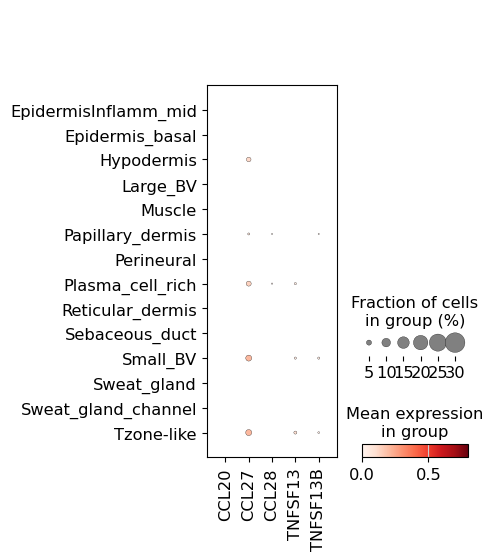

/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


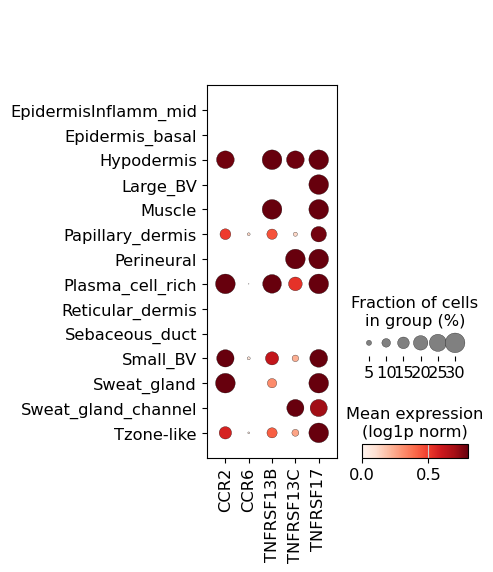

In [15]:
sc.pl.dotplot(
    adata[adata.obs["lvl5_annotation"]=="Plasma cell"],
     remove_markers(["CCL2", "CCL20",  "CCL27", "CCL28", 'TNFSF13', 'TNFSF13B']),
    groupby="niche19",
    vmax=0.8,
   # categories_order=ORDER,
        dot_max=0.3,

    #save='supp16_plasma_Cell_dotplot1_XENIUM.pdf'
)

sc.pl.dotplot(
    adata[adata.obs["lvl5_annotation"]=="Plasma cell"],
       remove_markers(["CCR2", "CCR6",  "CCR10", 'TNFRSF13B', 'TNFRSF13C', 'TNFRSF17']),
    groupby="niche19",
    vmax=0.8,
    dot_max=0.3,
    #categories_order=ORDER,
    colorbar_title="Mean expression\n(log1p norm)",
    #save='supp16_plasma_Cell_dotplot2_XENIUM.pdf'
)


In [23]:
adata_i.obs["niche19"].value_counts()
 

niche19
Papillary_dermis            13768
Small_BV                    13059
Reticular_dermis             8816
Tzone-like                   3907
Reticular_dermis_LE_rich     1279
Hypodermis                    824
Muscle                        608
Sweat_gland_channel           469
Perineural                    383
Sweat_gland                   361
VenuleMuscle                  239
Large_BV                      125
Sebaceous_gland                97
Nonspecific/folded             57
Sebaceous_duct                 49
Epidermis_basal                30
HF_outer                       21
Plasma_cell_rich               18
EpidermisInflamm_mid           16
Name: count, dtype: int64

/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


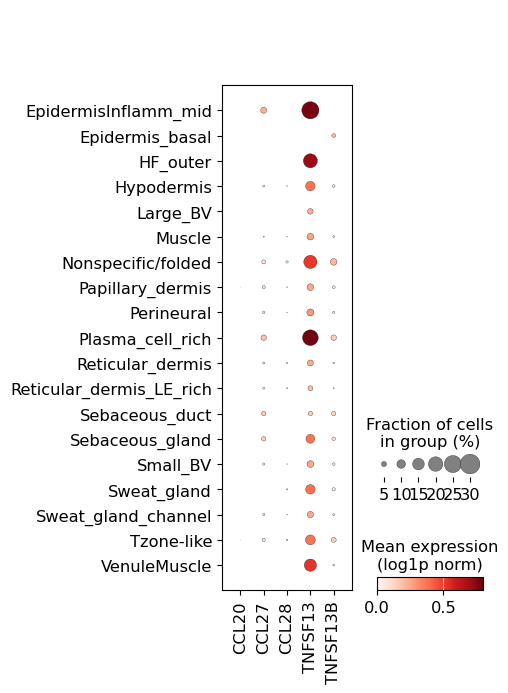

In [22]:
adata_i = adata[adata.obs["lvl5_annotation"]=="Mac2"]
# get counts
counts = adata_i.obs["niche19"].value_counts()

# keep categories with >=10 cells
keep = counts[counts >= 10].index

# filter AnnData
adata_i = adata_i[adata_i.obs["niche19"].isin(keep)].copy()
sc.pl.dotplot(
    adata_i,
     remove_markers(["CCL2", "CCL20",  "CCL27", "CCL28", 'TNFSF13', 'TNFSF13B']),
    groupby="niche19",
    vmax=0.8,
    dot_max=0.3,
    #categories_order=ORDER,
    colorbar_title="Mean expression\n(log1p norm)",
    #save='supp16_plasma_Cell_dotplot2_XENIUM.pdf'
)


/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


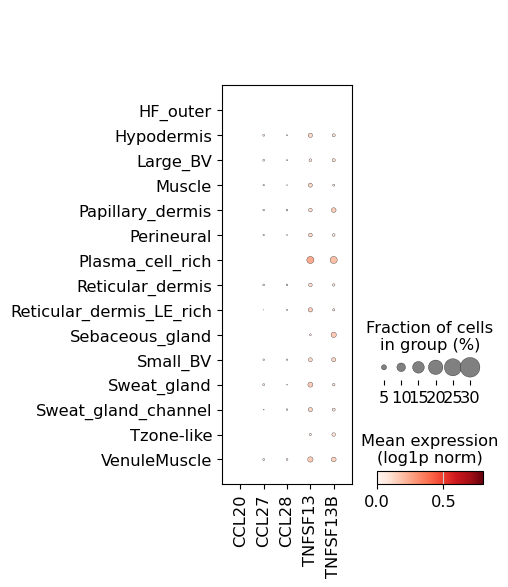

In [24]:
adata_i = adata[adata.obs["lvl5_annotation"]=="F2/3: Perivascular"]
# get counts
counts = adata_i.obs["niche19"].value_counts()

# keep categories with >=10 cells
keep = counts[counts >= 10].index

# filter AnnData
adata_i = adata_i[adata_i.obs["niche19"].isin(keep)].copy()
sc.pl.dotplot(
    adata_i,
     remove_markers(["CCL2", "CCL20",  "CCL27", "CCL28", 'TNFSF13', 'TNFSF13B']),
    groupby="niche19",
    vmax=0.8,
    dot_max=0.3,
    #categories_order=ORDER,
    colorbar_title="Mean expression\n(log1p norm)",
    #save='supp16_plasma_Cell_dotplot2_XENIUM.pdf'
)


In [32]:

KEEP = ['BK50_Past Lesional', 'BK49_Past Lesional wk8 relaspe', 'BK46_Never Lesional', 'BK51_Past Lesional wk8 relaspe', 'BK51_wk8 Relapse', 'BK46_Past Lesional', 'BK43_Past Lesional', 'BK43_Never Lesional', 'BK49_wk8 Relapse', 'BK49_Past Lesional', 'BK49_Never Lesional', 'BK51_Never Lesional', 'BK50_Never Lesional', 'BK51_Past Lesional']

adata.obs["remission"] = [x if x in KEEP else "other" for x in adata.obs["info_id6"]]

{x:x for x in adata.obs["remission"].unique()}


{'BK50_Past Lesional': 'BK50_Past Lesional',
 'BK49_Past Lesional wk8 relaspe': 'BK49_Past Lesional wk8 relaspe',
 'BK46_Never Lesional': 'BK46_Never Lesional',
 'BK51_Past Lesional wk8 relaspe': 'BK51_Past Lesional wk8 relaspe',
 'BK51_wk8 Relapse': 'BK51_wk8 Relapse',
 'BK46_Past Lesional': 'BK46_Past Lesional',
 'BK43_Past Lesional': 'BK43_Past Lesional',
 'BK43_Never Lesional': 'BK43_Never Lesional',
 'BK49_wk8 Relapse': 'BK49_wk8 Relapse',
 'BK49_Past Lesional': 'BK49_Past Lesional',
 'BK49_Never Lesional': 'BK49_Never Lesional',
 'BK51_Never Lesional': 'BK51_Never Lesional',
 'BK50_Never Lesional': 'BK50_Never Lesional',
 'BK51_Past Lesional': 'BK51_Past Lesional',
 'other': 'other'}

In [33]:

RENAME = {'BK50_Past Lesional': 'Past Lesional',
 'BK49_Past Lesional wk8 relaspe': 'wk8 relaspe',
 'BK46_Never Lesional': 'Never Lesional',
 'BK51_Past Lesional wk8 relaspe': 'wk8 relaspe',
 'BK51_wk8 Relapse': 'wk8 relapse',
 'BK46_Past Lesional': 'Past Lesional',
 'BK43_Past Lesional': 'Past Lesional',
 'BK43_Never Lesional': 'Never Lesional',
 'BK49_wk8 Relapse': 'wk8 relapse',
 'BK49_Past Lesional': 'Past Lesional',
 'BK49_Never Lesional': 'Never Lesional',
 'BK51_Never Lesional': 'Never Lesional',
 'BK50_Never Lesional': 'Never Lesional',
 'BK51_Past Lesional': 'Past Lesional',
 'other': 'other'}
adata.obs["remission"]=adata.obs["remission"].map(RENAME)


/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/anndata/_core/anndata.py:1146: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/anndata/_core/anndata.py:1146: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


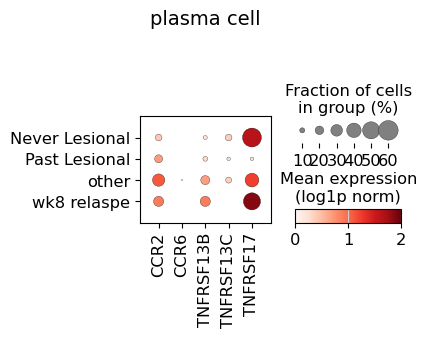

/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/anndata/_core/anndata.py:1146: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/anndata/_core/anndata.py:1146: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


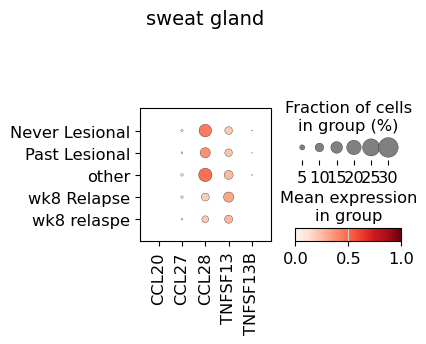

/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/anndata/_core/anndata.py:1146: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/anndata/_core/anndata.py:1146: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


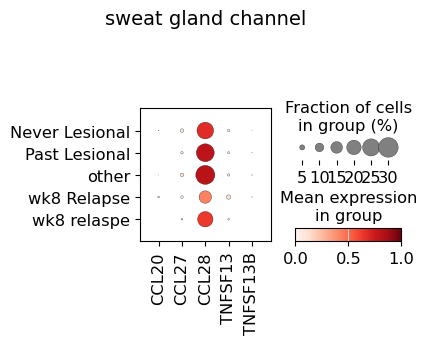

In [34]:
sc.pl.dotplot(
    adata[adata.obs["lvl5_annotation"]=="Plasma cell"],
       remove_markers(["CCR2", "CCR6",   "CCR10", 'TNFRSF13B', 'TNFRSF13C', 'TNFRSF17']),
    groupby="remission",
    vmax=2,
    dot_max=0.6,
    #categories_order=ORDER,
    colorbar_title="Mean expression\n(log1p norm)",
    title="plasma cell",

    #save='supp16_plasma_Cell_dotplot2_XENIUM.pdf'
)
sc.pl.dotplot(
    adata[adata.obs["lvl5_annotation"]=="Sweat gland"],
     remove_markers(["CCL2", "CCL20", "CCL27", "CCL28", 'TNFSF13', 'TNFSF13B']),
    groupby="remission",
    vmax=1,
   # categories_order=ORDER,
        dot_max=.3,
title="sweat gland",
    #save='supp16_plasma_Cell_dotplot1_XENIUM.pdf'
)
sc.pl.dotplot(
    adata[adata.obs["lvl5_annotation"].str.startswith("Sweat gland channel")],
     remove_markers(["CCL2", "CCL20",   "CCL27", "CCL28", 'TNFSF13', 'TNFSF13B']),
    groupby="remission",
    vmax=1,
   # categories_order=ORDER,
        dot_max=.3,
title="sweat gland channel",

    #save='supp16_plasma_Cell_dotplot1_XENIUM.pdf'
)

In [36]:

[x for  x,v in {'BK50_Past Lesional': 'BK50_Past Lesional',
 'BK49_Past Lesional wk8 relaspe': 'BK49_Past Lesional wk8 relaspe',
 'BK46_Never Lesional': 'BK46_Never Lesional',
 'BK51_Past Lesional wk8 relaspe': 'BK51_Past Lesional wk8 relaspe',
 'BK51_wk8 Relapse': 'BK51_wk8 Relapse',
 'BK46_Past Lesional': 'BK46_Past Lesional',
 'BK43_Past Lesional': 'BK43_Past Lesional',
 'BK43_Never Lesional': 'BK43_Never Lesional',
 'BK49_wk8 Relapse': 'BK49_wk8 Relapse',
 'BK49_Past Lesional': 'BK49_Past Lesional',
 'BK49_Never Lesional': 'BK49_Never Lesional',
 'BK51_Never Lesional': 'BK51_Never Lesional',
 'BK50_Never Lesional': 'BK50_Never Lesional',
 'BK51_Past Lesional': 'BK51_Past Lesional' }.items()]

['BK50_Past Lesional',
 'BK49_Past Lesional wk8 relaspe',
 'BK46_Never Lesional',
 'BK51_Past Lesional wk8 relaspe',
 'BK51_wk8 Relapse',
 'BK46_Past Lesional',
 'BK43_Past Lesional',
 'BK43_Never Lesional',
 'BK49_wk8 Relapse',
 'BK49_Past Lesional',
 'BK49_Never Lesional',
 'BK51_Never Lesional',
 'BK50_Never Lesional',
 'BK51_Past Lesional']

/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/anndata/_core/anndata.py:1146: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/anndata/_core/anndata.py:1146: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


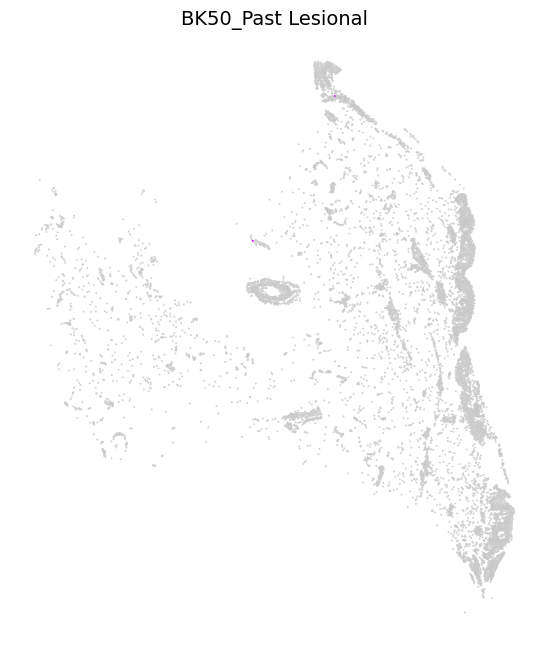

/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/anndata/_core/anndata.py:1146: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/anndata/_core/anndata.py:1146: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


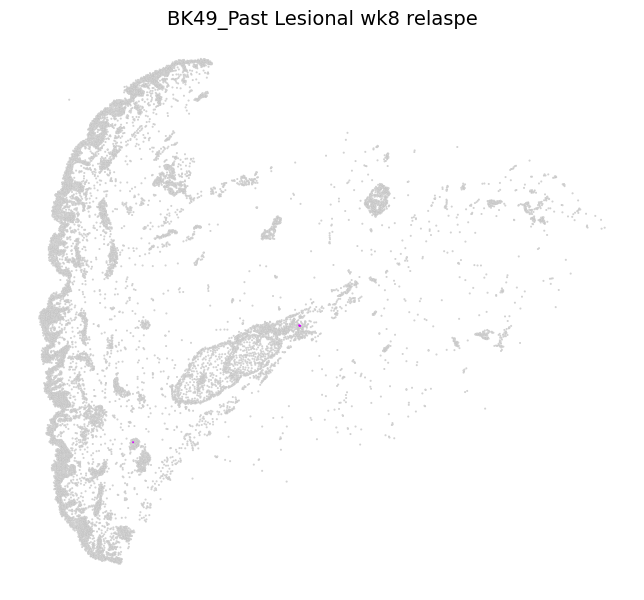

/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/anndata/_core/anndata.py:1146: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/anndata/_core/anndata.py:1146: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


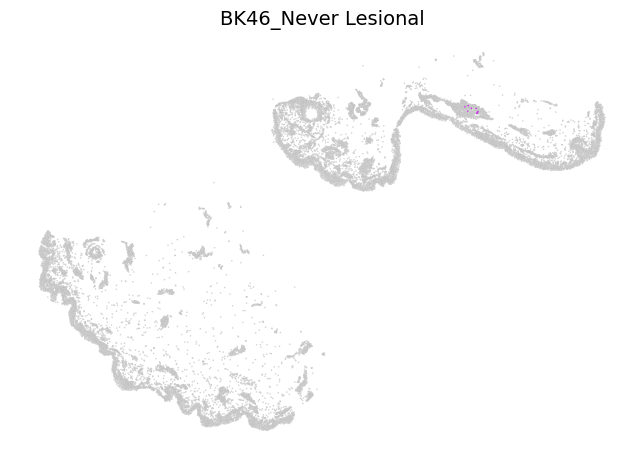

/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/anndata/_core/anndata.py:1146: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/anndata/_core/anndata.py:1146: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


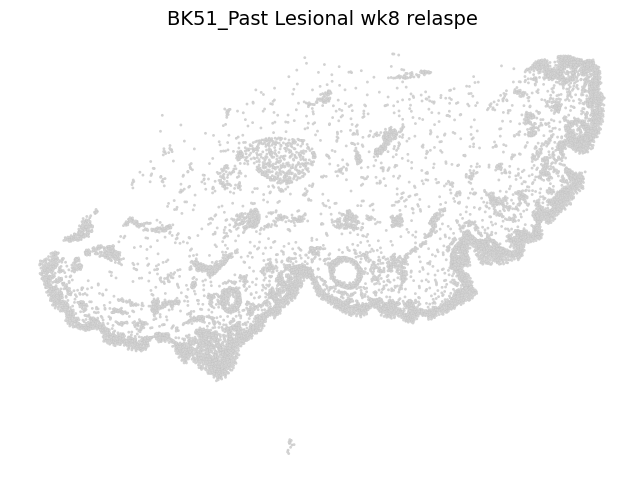

/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/anndata/_core/anndata.py:1146: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/anndata/_core/anndata.py:1146: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


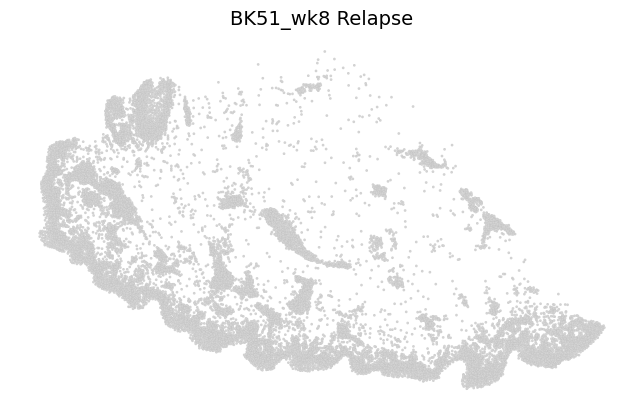

/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/anndata/_core/anndata.py:1146: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/anndata/_core/anndata.py:1146: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


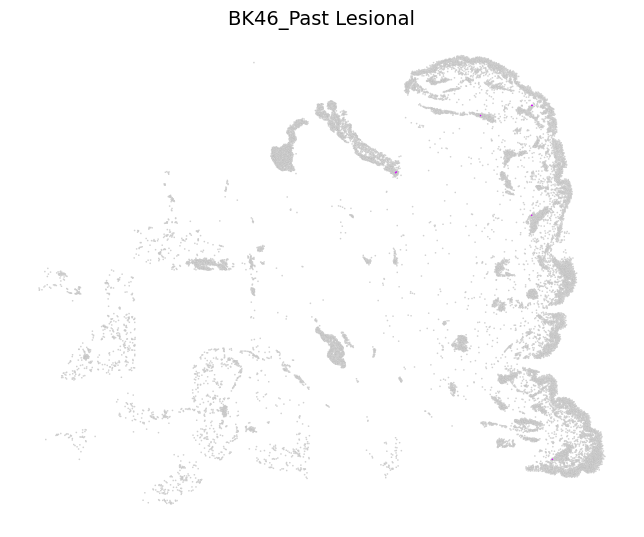

/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/anndata/_core/anndata.py:1146: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/anndata/_core/anndata.py:1146: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


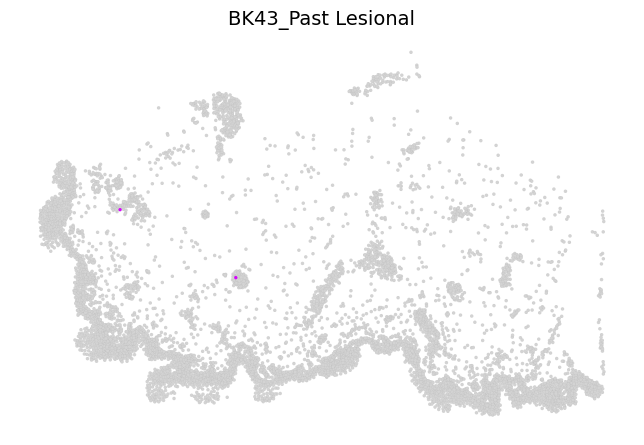

/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/anndata/_core/anndata.py:1146: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/anndata/_core/anndata.py:1146: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


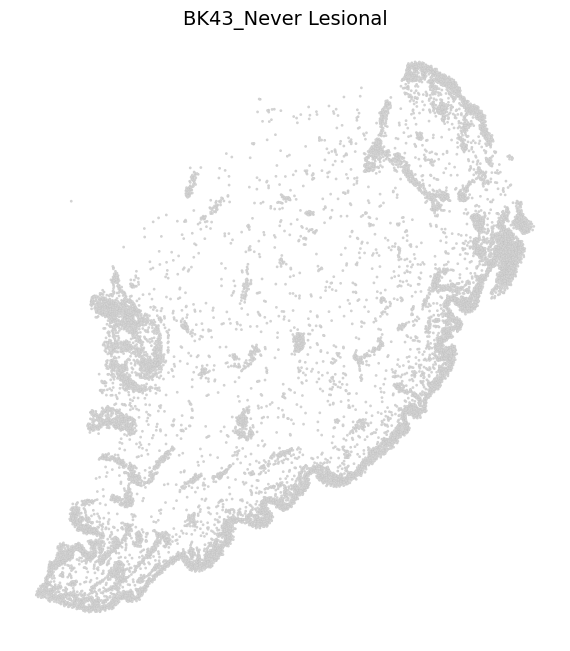

/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/anndata/_core/anndata.py:1146: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/anndata/_core/anndata.py:1146: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


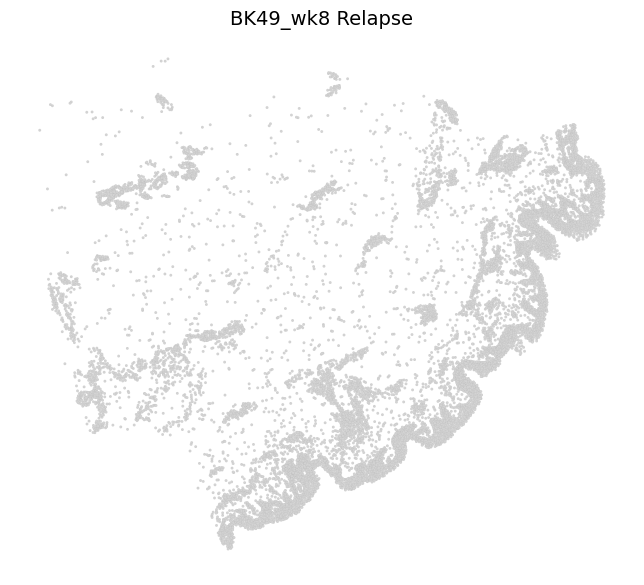

/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/anndata/_core/anndata.py:1146: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/anndata/_core/anndata.py:1146: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


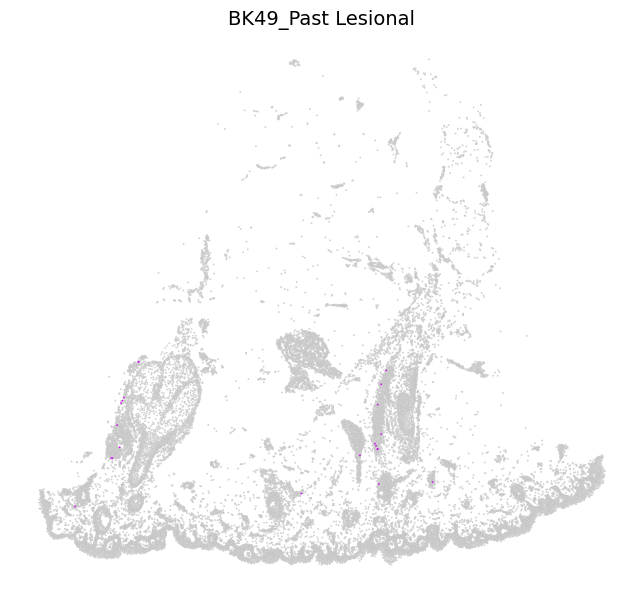

/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/anndata/_core/anndata.py:1146: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/anndata/_core/anndata.py:1146: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


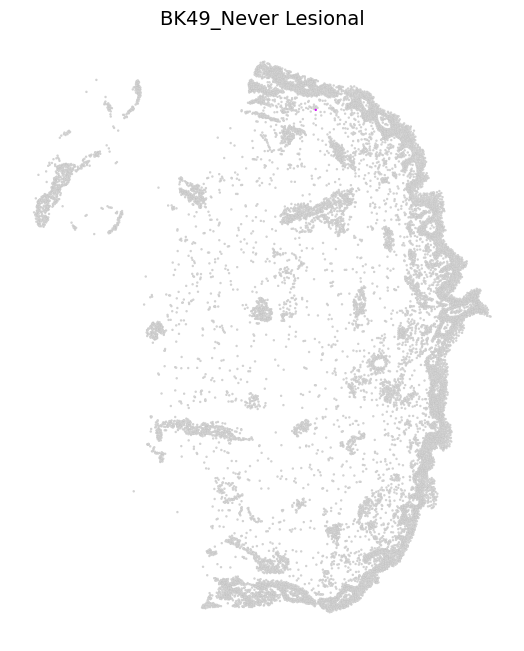

/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/anndata/_core/anndata.py:1146: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/anndata/_core/anndata.py:1146: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


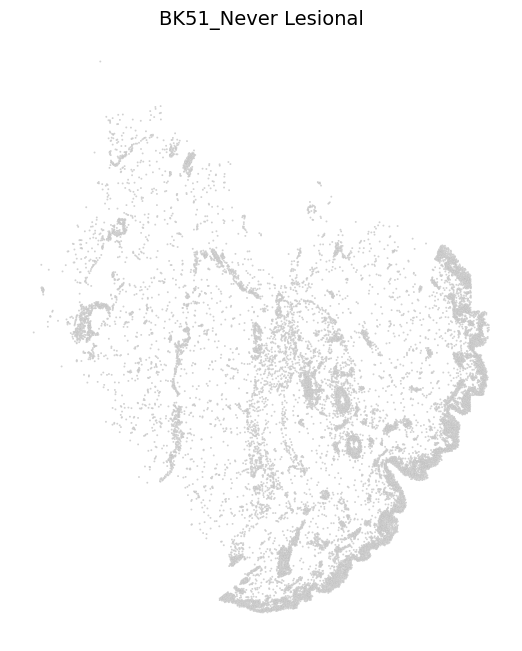

/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/anndata/_core/anndata.py:1146: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/anndata/_core/anndata.py:1146: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


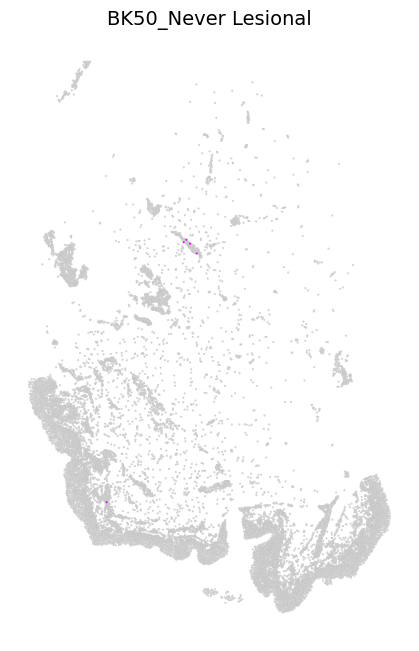

/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/anndata/_core/anndata.py:1146: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/anndata/_core/anndata.py:1146: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


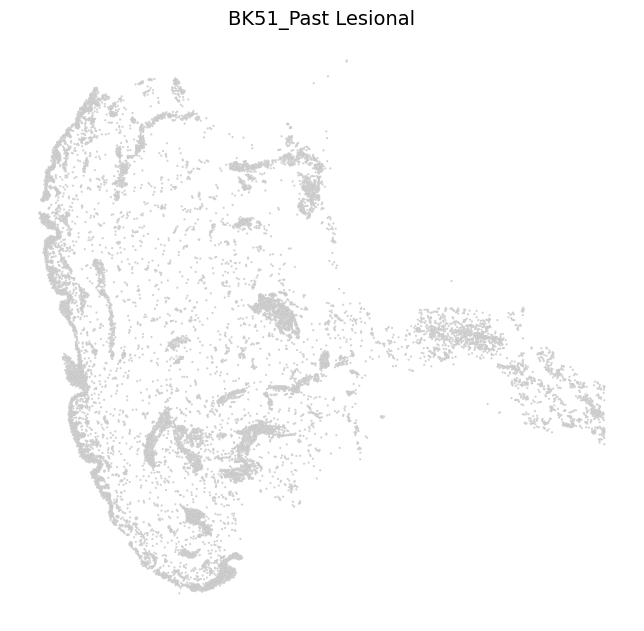

In [38]:
sc.settings.set_figure_params(dpi=50, dpi_save=300, facecolor="white", frameon=False, figsize=(8,8),
                                   vector_friendly=True
                             )


for x in ['BK50_Past Lesional',
 'BK49_Past Lesional wk8 relaspe',
 'BK46_Never Lesional',
 'BK51_Past Lesional wk8 relaspe',
 'BK51_wk8 Relapse',
 'BK46_Past Lesional',
 'BK43_Past Lesional',
 'BK43_Never Lesional',
 'BK49_wk8 Relapse',
 'BK49_Past Lesional',
 'BK49_Never Lesional',
 'BK51_Never Lesional',
 'BK50_Never Lesional',
 'BK51_Past Lesional']:
    adata_i=adata[adata.obs["info_id6"]==x]

   
    sc.pl.spatial(
        adata_i,#[adata_i.obs["Timepoint"].str.startswith("Les")],
       # library_id="spatial",
      #  shape=None,
        color=["lvl5_annotation"],
        spot_size=15,
        vmax=1,
                edgecolor="black",
        linewidth=0.01,
                legend_fontsize=12,
      title=x,
        legend_loc=None,
          # cmap="Reds"
        groups=["Plasma cell"],
    )
    #     if i>1:
    #         break

 
 


In [39]:
adata_i=adata[adata.obs["remission"]!="other"]
adata_i.obs["remission"].value_counts()

remission
Past Lesional     75050
Never Lesional    74463
wk8 Relapse       25836
wk8 relaspe       23372
Name: count, dtype: int64

niche19
Small_BV            27
Papillary_dermis    12
Plasma_cell_rich     6
Tzone-like           4
Perineural           2
Name: count, dtype: int64

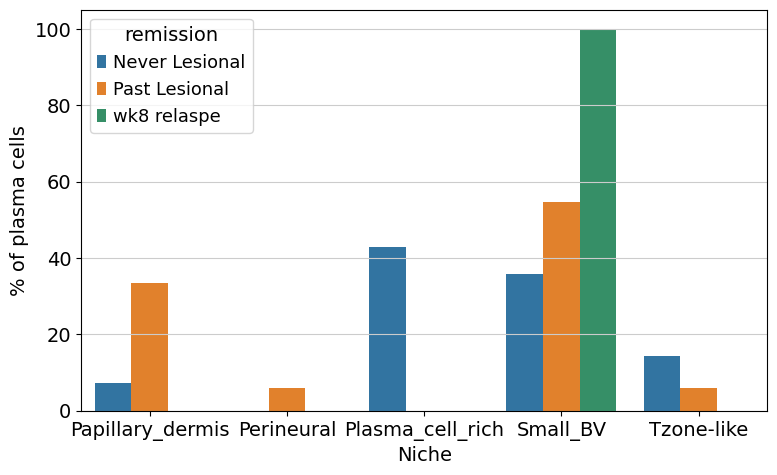

In [44]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Subset to plasma cells
plasma = adata_i[adata_i.obs["lvl5_annotation"] == "Plasma cell"].obs.copy()

# 2. Count plasma cells per niche and remission
counts = (
    plasma.groupby(["remission", "niche19"])
    .size()
    .reset_index(name="n_plasma")
)

# 3. Convert to percentage within each remission group
counts["pct_plasma"] = (
    counts.groupby("remission")["n_plasma"]
    .transform(lambda x: 100 * x / x.sum())
)

# 4. Plot
plt.figure(figsize=(8,5))

sns.barplot(
    data=counts,
    x="niche19",
    y="pct_plasma",
    hue="remission"
)

plt.ylabel("% of plasma cells")
plt.xlabel("Niche")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
adata[adata.obs["niche19"]=="Plasma_cell_rich"].obs.sample_id.value_counts().head(6).index

In [21]:
KEEP =['BK27_Week 12', 'BK27_Lesional Baseline',
                  'BK27_Non-lesional Baseline', 'BK20_Week 12', 'BK23_Week 12',
                  'BK24_Lesional Baseline']
adata.obs["pc"] = ["PC+" if x in KEEP else "other" for x in adata.obs["sample_id"]]

/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/anndata/_core/anndata.py:1146: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


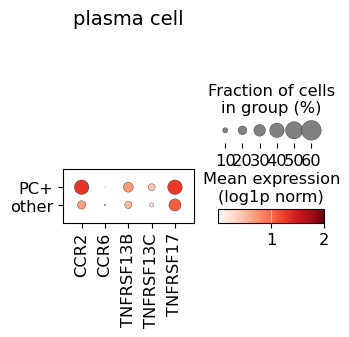

/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/anndata/_core/anndata.py:1146: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


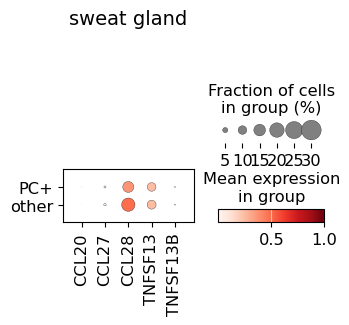

/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/anndata/_core/anndata.py:1146: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


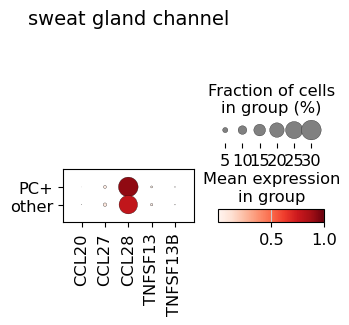

In [28]:
sc.pl.dotplot(
    adata[adata.obs["lvl5_annotation"]=="Plasma cell"],
       remove_markers(["CCR2", "CCR6",   "CCR10", 'TNFRSF13B', 'TNFRSF13C', 'TNFRSF17']),
    groupby="pc",
    vmax=2,
    dot_max=0.6,
    #categories_order=ORDER,
    colorbar_title="Mean expression\n(log1p norm)",
    title="plasma cell",

    #save='supp16_plasma_Cell_dotplot2_XENIUM.pdf'
)
sc.pl.dotplot(
    adata[adata.obs["lvl5_annotation"]=="Sweat gland"],
     remove_markers(["CCL2", "CCL20", "CCL27", "CCL28", 'TNFSF13', 'TNFSF13B']),
    groupby="pc",
    vmax=1,
   # categories_order=ORDER,
        dot_max=.3,
title="sweat gland",
    #save='supp16_plasma_Cell_dotplot1_XENIUM.pdf'
)
sc.pl.dotplot(
    adata[adata.obs["lvl5_annotation"].str.startswith("Sweat gland channel")],
     remove_markers(["CCL2", "CCL20",   "CCL27", "CCL28", 'TNFSF13', 'TNFSF13B']),
    groupby="pc",
    vmax=1,
   # categories_order=ORDER,
        dot_max=.3,
title="sweat gland channel",

    #save='supp16_plasma_Cell_dotplot1_XENIUM.pdf'
)

/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/anndata/_core/anndata.py:1146: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


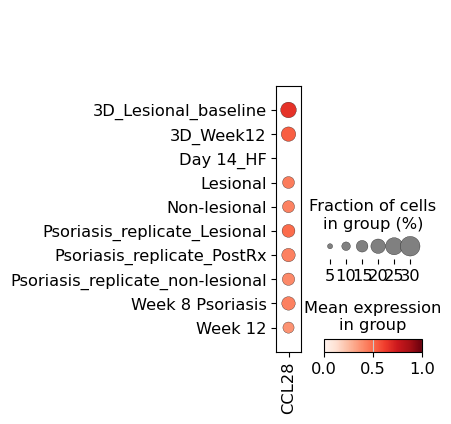

In [26]:
sc.pl.dotplot(
    adata[adata.obs["lvl5_annotation"]=="Sweat gland"],
     remove_markers([  "CCL28",  ]),
    groupby="Site_status",
    vmax=1,
   # categories_order=ORDER,
        dot_max=.3,

    #save='supp16_plasma_Cell_dotplot1_XENIUM.pdf'
)

In [30]:
9

9

In [ ]:
import pandas as pd

subset = adata.obs[adata.obs["niche19"].str.startswith("Plasma")]
vc = subset["lvl5_annotation"].value_counts()
vc


In [ ]:
vc_filtered = vc[vc >= 10]



adata=adata[(adata.obs["niche19"].str.startswith("Plasma"))|
           (adata.obs["lvl5_annotation"].str.startswith("Sweat"))|
              (adata.obs["lvl5_annotation"].str.startswith("Bc"))
           ]
adata=adata[(adata.obs["lvl5_annotation"].isin(vc_filtered.index.to_list()))
           |
              (adata.obs["lvl5_annotation"].str.startswith("Bc"))|
           (adata.obs["lvl5_annotation"].str.startswith("Sweat"))].copy()
adata.obs["lvl5_annotation"].value_counts()


In [ ]:

ORDER = [


 'Plasma cell',
     "Bcell",
 'Sweat gland Myoepithelial',
         'Sweat gland',
          'Sweat gland channel outer',
 'Sweat gland channel inner',
 'VE1_Art','VE3_Ven',
 'VE4_Cap',
    'Mac2',
 'T',

 'cDC1',
'F3: FRC-like', "F2/3: Perivascular", 'Pericyte1', 
    
    # 'mSchwann',
   # 'nmSchwann',
]
sc.pl.dotplot(
    adata,
     remove_markers(["CCL2", "CCL20",  "CCL27", "CCL28", 'TNFSF13', 'TNFSF13B']),
    groupby="lvl5_annotation",
    vmax=0.8,
    categories_order=[x for x in ORDER if x in adata.obs.lvl5_annotation.unique()],
        dot_max=0.3,

    save='supp16_plasma_Cell_dotplot1_XENIUM.pdf'
)

sc.pl.dotplot(
    adata,
       remove_markers(["CCR2", "CCR6", "CCR10", 'TNFRSF13B', 'TNFRSF13C', 'TNFRSF17']),
    groupby="lvl5_annotation",
    vmax=0.8,
    dot_max=0.3,
    categories_order=[x for x in ORDER if x in adata.obs.lvl5_annotation.unique()],
    colorbar_title="Mean expression\n(log1p norm)",
    save='supp16_plasma_Cell_dotplot2_XENIUM.pdf'
)

# dp = dp.style(
#     cmap='Reds',
#     color_on='square',
#     dot_edge_color='white',
#     dot_edge_lw=1,
#     grid=False,
#     dot_max=0.6,
#     categories_order=ORDER
# )

# dp.savefig("fig5/", dpi=300)

# #dp.show()
   

In [ ]:

# sc.pp.normalize_total(adata, target_sum=1e4)
# sc.pp.log1p(adata)

# adata=adata[(adata.obs["niche19"].str.startswith("Plasma"))|
#            (adata.obs["lvl5_annotation"].str.startswith("Sweat"))
#            ]
adata=adata[(adata.obs["lvl5_annotation"].isin(vc_filtered.index.to_list()))
           |
           (adata.obs["lvl5_annotation"].str.startswith("Sweat"))].copy()
adata.obs["lvl5_annotation"].value_counts()


In [ ]:
sc.pl.dotplot(
    adata,
     remove_markers(["CCL2", "CCL20", "CCL28", 'TNFSF13', 'TNFSF13B']),
    groupby="lvl5_annotation",
    vmax=0.8,
   # categories_order=ORDER,
        dot_max=0.3,

    #save='supp16_plasma_Cell_dotplot1_XENIUM_allcells.pdf'
)

sc.pl.dotplot(
    adata,
       remove_markers(["CCR2", "CCR6", "CCR10", 'TNFRSF13B', 'TNFRSF13C', 'TNFRSF17']),
    groupby="lvl5_annotation",
    vmax=0.8,
    dot_max=0.3,
    #categories_order=ORDER,
    colorbar_title="Mean expression\n(log1p norm)",
    #save='supp16_plasma_Cell_dotplot2_XENIUM_allcells.pdf'
)

# dp = dp.style(
#     cmap='Reds',
#     color_on='square',
#     dot_edge_color='white',
#     dot_edge_lw=1,
#     grid=False,
#     dot_max=0.6,
#     categories_order=ORDER
# )

# dp.savefig("fig5/", dpi=300)

# #dp.show()
   

In [ ]:
# sc.pl.dotplot(
#     adata,
#      remove_markers(["PIGR",]),
#     groupby="lvl5_annotation",
#     vmax=0.8,
#     categories_order=ORDER,
#         dot_max=0.6,

#     save='4k_plasma_Cell_PIGRxenium.pdf'
# )


In [ ]:
# requested plot


In [ ]:
# sc.settings.set_figure_params(dpi_save=600, facecolor="white", frameon=False, figsize=(17,17))

# NICHE =  'Plasma_cell_rich'
# MIN_NUMBER_CELLS=10

# CORE_PAPER =["BK23_Week 12",
#                                        "BK27_Week 12",
#                                       'BK27_Lesional Baseline',
#                                          'BK24_Lesional Baseline']
# for i, tissue_section_id in enumerate(CORE_PAPER):
#     print(tissue_section_id)
#    # print(i, "/", len(adata_5k.obs["info_id6"].unique()))
#     adata_i =  adata[adata.obs["info_id6"]==tissue_section_id]


#     sc.pl.spatial(
#         adata_i,#[adata_i.obs["Timepoint"].str.startswith("Les")],
#        # library_id="spatial",
#       #  shape=None,
#         color=["TNFSF13"],
#         spot_size=10,
#         vmax=1,
#                 edgecolor="black",
#         linewidth=0.02,
#                 legend_fontsize=12,
#       #  title=x,
#         legend_loc=None,
#            cmap="Reds",
#         save=f"plotAPRILspatial_{i}.pdf"
#     )
#     #     if i>1:
#     #         break

 
 
       

In [ ]:
# for x in [ 'BK39_Lesional Baseline',  'BK22_Lesional Baseline',
#           'Lesional_CE3-SKI-24-FO-1-S22-A1',
#         #  'Lesional_Baseline_resolved_CE3-SKI-24-FO-1-S22_replicate',
#           # 'Lesional_CE3-SKI-24-FO-1-S22_replicate',
#            'Lesional_CE4-SKI-27-FO-4-S22-A2',
#       #'Lesional_CE4-SKI-27-FO-4-S22_replicate',

#          ]:
#     adata_i=adata[adata.obs["info_id6"]==x]

   
#     sc.pl.spatial(
#         adata_i,#[adata_i.obs["Timepoint"].str.startswith("Les")],
#        # library_id="spatial",
#       #  shape=None,
#         color=["TNFSF13"],
#         spot_size=10,
#         vmax=1,
#                 edgecolor="black",
#         linewidth=0.05,
#                 legend_fontsize=12,
#       #  title=x,
#         legend_loc=None,
#            cmap="Reds"
#     )
#     #     if i>1:
#     #         break

 
 


In [ ]:
# sc.pl.dotplot(
#     adata,
#      remove_markers([ 'TNFSF13', 
#                     'TNFRSF17'
#                     ]),
#     groupby="lvl5_annotation",
#     vmax=0.8,
#         dot_max=0.3,
#     save='plotTNFRSF17_TNFSF13_xenium.pdf',
#     swap_axes=True,
#     title="TNFSF13(APRIL) + TNFRSF17 expression in xenium"

#   #  save='supp16_plasma_Cell_dotplot1_XENIUM_allcells.pdf'
# )


In [ ]:
adata_plasma=adata[(adata.obs["lvl5_annotation"]=="Plasma cell")|
                  (adata.obs["lvl5_annotation"]=="Bcell")
                  ]
adata_plasma.shape


In [ ]:
adata_plasma.obs["niche19"].value_counts()

In [ ]:
sc.pl.dotplot(
    adata,
     remove_markers([ #'TNFSF13', 
                    #'TNFRSF17', 
                     "IGHE",
                    ]),
    groupby="lvl5_annotation",
    vmax=0.8,
        dot_max=0.3,
    swap_axes=True

  #  save='supp16_plasma_Cell_dotplot1_XENIUM_allcells.pdf'
)


In [ ]:
niche_counts = adata_plasma.obs["niche19"].value_counts()
valid = niche_counts[niche_counts >= 10].index
adata_plasma = adata_plasma[adata_plasma.obs["niche19"].isin(valid)].copy()
adata_plasma.obs["niche19"] = adata_plasma.obs["niche19"].cat.remove_unused_categories()

In [ ]:
sc.pl.dotplot(
    adata_plasma,#[adata_plasma.obs["lvl5_annotation"]=="Plasma cell"],
     remove_markers([  
                     "IGHE",
                    ]),
    groupby="lvl5_annotation",
    vmax=0.8,
        dot_max=0.3,
    swap_axes=True,
    title="IGHE expression in B cells + plasma cells(Xenium)"

  #  save='supp16_plasma_Cell_dotplot1_XENIUM_allcells.pdf'
)


In [ ]:
sc.pl.dotplot(
    adata_plasma[adata_plasma.obs["lvl5_annotation"]=="Plasma cell"],
     remove_markers([  
                     "IGHE",
                    ]),
    groupby="niche19",
    vmax=0.8,
        dot_max=0.3,
    swap_axes=True,
        save="IGs_inplasmacell_byniche.pdf",
    title="IGHE expression in plasma cells by niche (Xenium)"


  #  save='supp16_plasma_Cell_dotplot1_XENIUM_allcells.pdf'
)


In [ ]:
# sc.pl.dotplot(
#     adata,
#      remove_markers([ 'TNFSF13', 
#                     'TNFRSF17', 
#                      "IGHE",
#                     ]),
#     groupby="",
#     vmax=0.8,
#         dot_max=0.3,
#     swap_axes=True

#   #  save='supp16_plasma_Cell_dotplot1_XENIUM_allcells.pdf'
# )


In [ ]:
adata_plasma=adata[(adata.obs["lvl5_annotation"]=="Plasma cell")|
                  (adata.obs["lvl5_annotation"]=="Bcell")
                  ]
adata_plasma.shape


In [ ]:
adata_plasma.obs["lvl5_annotation"].value_counts()

In [ ]:
adata_plasma.obs["Site_status"].value_counts()

In [ ]:
adata_plasma_l = adata_plasma[(adata_plasma.obs["Site_status"]=="Week 12")|
                              (adata_plasma.obs["Site_status"]=="Lesional")|
                              (adata_plasma.obs["Site_status"].str.startswith("3D"))|
                               (adata_plasma.obs["Site_status"]=="Psoriasis_replicate_Lesional")
                              
                               ]


In [ ]:
adata_plasma_l.obs["t"] = adata_plasma_l.obs["lvl5_annotation"].astype(str)+"_" + adata_plasma_l.obs["Patient_status"].astype(str) + adata_plasma_l.obs["Site_status"].astype(str)

{x:x for x in adata_plasma_l.obs["t"].unique()}



In [ ]:
adata_plasma_l[adata_plasma_l.obs["t"]== 'Plasma cell_3d_Week123D_Week12'].obs.info_id6.value_counts()

In [ ]:
RENAME = {'Plasma cell_ADLesional': 'Plasma cell_AD_Lesional',
 'Bcell_ADLesional': 'Bcell_AD_Lesional',
 'Bcell_ADWeek 12': 'Bcell_AD_Week12',
 'Plasma cell_ADWeek 12': 'Plasma cell_AD_Week12',
 'Plasma cell_PsoriasisLesional': 'Plasma cell_Psoriasis_Lesional',
 'Bcell_PsoriasisLesional': 'Bcell_Psoriasis_Lesional',
 'Bcell_nanPsoriasis_replicate_Lesional': 'Bcell_Psoriasis_Lesional',
 'Plasma cell_nanPsoriasis_replicate_Lesional': 'Plasma cell_Psoriasis_Lesional',
 'Bcell_3d_Lesional_baseline3D_Lesional_baseline': 'Bcell_AD_Lesional',
 'Plasma cell_3d_Lesional_baseline3D_Lesional_baseline': 'Plasma cell_AD_Lesional',
 'Bcell_3d_Week123D_Week12': 'Bcell_AD_Week12',
 'Plasma cell_3d_Week123D_Week12': 'Plasma cell_AD_Week12',
 'Plasma cell_3d_Lesional_baseline3D_Week12': 'Plasma cell_AD_Week12',
 'Bcell_3d_Lesional_baseline3D_Week12': 'Bcell_AD_Week12'}
adata_plasma_l.obs["t2"]=adata_plasma_l.obs["t"].map(RENAME)
adata_plasma_l.obs["t2"].value_counts()
# exclude = ['Bcell_nanPsoriasis_replicate_Lesional',
           
#           ]
# adata_plasma_l=adata_plasma_l[~adata_plasma_l.obs["t"].isin(exclude)]

In [ ]:
heavy_genes = ["IGHM", "IGHD", "IGHG1", "IGHG2", "IGHG3", "IGHG4", "IGHA1", "IGHA2", "IGHE"]
sc.pl.dotplot(
    adata_plasma_l,
     remove_markers(heavy_genes),
    groupby="t2",
    vmax=0.8,
    swap_axes=True,
     dot_max=0.3,

    save='plotIGS_xenium.pdf',
    colorbar_title='Mean expression\n(log1p norm)'

)


In [ ]:
adata_plasma_l.obs.niche19.value_counts()

In [ ]:
niche_counts = adata_plasma_l.obs["niche19"].value_counts()
valid = niche_counts[niche_counts >= 10].index
adata_plasma_l = adata_plasma_l[adata_plasma_l.obs["niche19"].isin(valid)].copy()
adata_plasma_l.obs["niche19"] = adata_plasma_l.obs["niche19"].cat.remove_unused_categories()

In [ ]:
sc.pl.dotplot(
    adata_plasma_l[adata_plasma_l.obs["lvl5_annotation"]=="Plasma cell"],
     remove_markers([  
                     "IGHE",
                    ]),
    groupby="niche19",
    vmax=0.8,
        dot_max=0.3,
    swap_axes=True,
       # save="IGs_inplasmacell_byniche.pdf",
    title="IGHE expression in plasma cells by niche (Xenium)",
    save="IGs_by_niche.pdf"

  #  save='supp16_plasma_Cell_dotplot1_XENIUM_allcells.pdf'
)


In [ ]:
sc.pl.dotplot(
    adata_plasma_l[adata_plasma_l.obs["lvl5_annotation"]=="Bcell"],
     remove_markers([  
                     "IGHE",
                    ]),
    groupby="niche19",
    vmax=0.8,
        dot_max=0.3,
    swap_axes=True,
     save="IGs_inBcell_byniche.pdf",
    title="IGHE expression in B cells by niche (Xenium)"


  #  save='supp16_plasma_Cell_dotplot1_XENIUM_allcells.pdf'
)


In [ ]:
vc_filtered = vc[vc >= 10]

adata=adata[(adata.obs["niche19"].str.startswith("Plasma"))
           ]
adata=adata[(adata.obs["lvl5_annotation"].isin(vc_filtered.index.to_list()))]
adata.obs["lvl5_annotation"].value_counts()

import pandas as pd
CATEGORY="lvl5_annotation"
sc.tl.rank_genes_groups(adata, CATEGORY, method='wilcoxon', key_added="de_leiden");
df2 = pd.DataFrame(adata.uns['de_leiden']['names'])
for i,x in enumerate(df2.columns):
    print(i, " : ", x) 

In [ ]:
df2.head(50)


### 